In [3]:
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler,MinMaxScaler
df=pd.read_csv('kc_house_filtered.csv')
df

,price,bedrooms,bathrooms,sqft_living,floors,waterfront,yr_built,condition
0,221900.0,3,1.00,1180,1.0,0,1955,3
1,538000.0,3,2.25,2570,2.0,0,1951,3
2,180000.0,2,1.00,770,1.0,0,1933,3
3,604000.0,4,3.00,1960,1.0,0,1965,5
4,510000.0,3,2.00,1680,1.0,0,1987,3
...,...,...,...,...,...,...,...,...
21608,360000.0,3,2.50,1530,3.0,0,2009,3
21609,400000.0,4,2.50,2310,2.0,0,2014,3
21610,402101.0,2,0.75,1020,2.0,0,2009,3
21611,400000.0,3,2.50,1600,2.0,0,2004,3


In [6]:
def find_caps(coloumn_data):
    Q1=coloumn_data.quantile(0.25)
    Q3=coloumn_data.quantile(0.75)
    IQR=Q3-Q1
    lower_cap=Q1-1.5*IQR
    upper_cap=Q3+1.5*IQR
    return lower_cap,upper_cap
for col in['price','sqft_living','bedrooms']:
    lower,upper=find_caps(df[col])
    outliers_count=((df[col]<lower)|(df[col]>upper)).sum()
    df[col]=df[col].clip(lower=lower,upper=upper)
    print(f"capped{outliers_count} outliers in")
    #clip=lower sai niche lower fill upper sai uper upper

capped1146 outliers in
capped572 outliers in
capped546 outliers in


In [7]:
df.dtypes

price          float64
bedrooms       float64
bathrooms      float64
sqft_living    float64
floors         float64
waterfront       int64
yr_built         int64
condition        int64
dtype: object

<Axes: xlabel='bedrooms'>

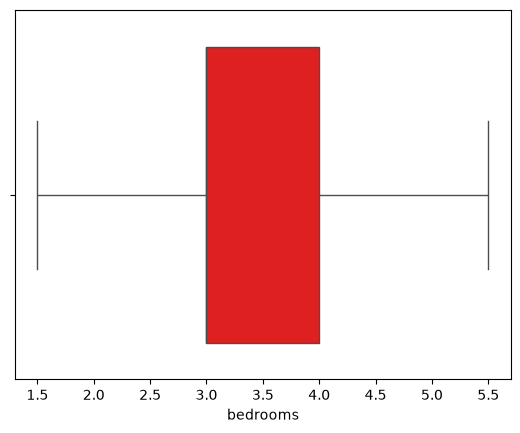

In [8]:
sns.boxplot(data=df,x='bedrooms',color='red')

<Axes: xlabel='price', ylabel='Count'>

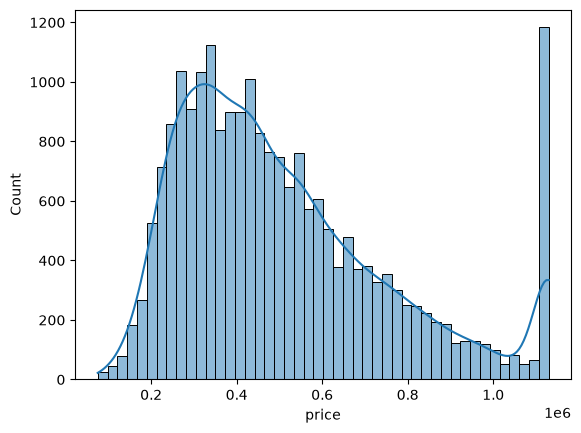

In [9]:
import seaborn as sns
sns.histplot(data=df,x='price',kde=True)

In [10]:
#standarad scalar min max scalar
from sklearn.preprocessing import StandardScaler,MinMaxScaler
minmax_scaler=MinMaxScaler()
df['scaled_size']=minmax_scaler.fit_transform(df[['sqft_living']])
df


,price,bedrooms,bathrooms,sqft_living,floors,waterfront,yr_built,condition,scaled_size
0,221900.0,3.0,1.00,1180.0,1.0,0,1955,3,0.225631
1,538000.0,3.0,2.25,2570.0,2.0,0,1951,3,0.578020
2,180000.0,2.0,1.00,770.0,1.0,0,1933,3,0.121688
3,604000.0,4.0,3.00,1960.0,1.0,0,1965,5,0.423374
4,510000.0,3.0,2.00,1680.0,1.0,0,1987,3,0.352389
...,...,...,...,...,...,...,...,...,...
21608,360000.0,3.0,2.50,1530.0,3.0,0,2009,3,0.314362
21609,400000.0,4.0,2.50,2310.0,2.0,0,2014,3,0.512105
21610,402101.0,2.0,0.75,1020.0,2.0,0,2009,3,0.185068
21611,400000.0,3.0,2.50,1600.0,2.0,0,2004,3,0.332108


In [11]:
std_scaler=StandardScaler()
df['year_scaled']=std_scaler.fit_transform(df[['yr_built']])
df
                                           

,price,bedrooms,bathrooms,sqft_living,floors,waterfront,yr_built,condition,scaled_size,year_scaled
0,221900.0,3.0,1.00,1180.0,1.0,0,1955,3,0.225631,-0.544898
1,538000.0,3.0,2.25,2570.0,2.0,0,1951,3,0.578020,-0.681079
2,180000.0,2.0,1.00,770.0,1.0,0,1933,3,0.121688,-1.293892
3,604000.0,4.0,3.00,1960.0,1.0,0,1965,5,0.423374,-0.204446
4,510000.0,3.0,2.00,1680.0,1.0,0,1987,3,0.352389,0.544548
...,...,...,...,...,...,...,...,...,...,...
21608,360000.0,3.0,2.50,1530.0,3.0,0,2009,3,0.314362,1.293542
21609,400000.0,4.0,2.50,2310.0,2.0,0,2014,3,0.512105,1.463768
21610,402101.0,2.0,0.75,1020.0,2.0,0,2009,3,0.185068,1.293542
21611,400000.0,3.0,2.50,1600.0,2.0,0,2004,3,0.332108,1.123316


In [12]:
#one-hot encoding used to give label
np.random.seed(42)
neighborhoods=['budget','mid-range','premium']
df['Neighborhood']=np.random.choice(neighborhoods,size=len(df))
print("Neighborhood tiers before encoding")
print(df['Neighborhood'].value_counts())

Neighborhood tiers before encoding
Neighborhood
budget       7240
mid-range    7223
premium      7150
Name: count, dtype: int64


In [13]:
df

,price,bedrooms,bathrooms,sqft_living,floors,waterfront,yr_built,condition,scaled_size,year_scaled,Neighborhood
0,221900.0,3.0,1.00,1180.0,1.0,0,1955,3,0.225631,-0.544898,premium
1,538000.0,3.0,2.25,2570.0,2.0,0,1951,3,0.578020,-0.681079,budget
2,180000.0,2.0,1.00,770.0,1.0,0,1933,3,0.121688,-1.293892,premium
3,604000.0,4.0,3.00,1960.0,1.0,0,1965,5,0.423374,-0.204446,premium
4,510000.0,3.0,2.00,1680.0,1.0,0,1987,3,0.352389,0.544548,budget
...,...,...,...,...,...,...,...,...,...,...,...
21608,360000.0,3.0,2.50,1530.0,3.0,0,2009,3,0.314362,1.293542,premium
21609,400000.0,4.0,2.50,2310.0,2.0,0,2014,3,0.512105,1.463768,premium
21610,402101.0,2.0,0.75,1020.0,2.0,0,2009,3,0.185068,1.293542,budget
21611,400000.0,3.0,2.50,1600.0,2.0,0,2004,3,0.332108,1.123316,budget


In [14]:
#one-hot encoding used pd.get dumies

df_encoded=pd.get_dummies(df,columns=['Neighborhood'],prefix="loc",dtype=int)
df_encoded

,price,bedrooms,bathrooms,sqft_living,floors,waterfront,yr_built,condition,scaled_size,year_scaled,loc_budget,loc_mid-range,loc_premium
0,221900.0,3.0,1.00,1180.0,1.0,0,1955,3,0.225631,-0.544898,0,0,1
1,538000.0,3.0,2.25,2570.0,2.0,0,1951,3,0.578020,-0.681079,1,0,0
2,180000.0,2.0,1.00,770.0,1.0,0,1933,3,0.121688,-1.293892,0,0,1
3,604000.0,4.0,3.00,1960.0,1.0,0,1965,5,0.423374,-0.204446,0,0,1
4,510000.0,3.0,2.00,1680.0,1.0,0,1987,3,0.352389,0.544548,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
21608,360000.0,3.0,2.50,1530.0,3.0,0,2009,3,0.314362,1.293542,0,0,1
21609,400000.0,4.0,2.50,2310.0,2.0,0,2014,3,0.512105,1.463768,0,0,1
21610,402101.0,2.0,0.75,1020.0,2.0,0,2009,3,0.185068,1.293542,1,0,0
21611,400000.0,3.0,2.50,1600.0,2.0,0,2004,3,0.332108,1.123316,1,0,0


In [15]:
final_cols=['price','bedrooms','bathrooms','sqft_living',
            'floors','waterfront','condition',
            'scaled_size','loc_budget',
            'loc_mid-range','loc_premium']
df_final=df_encoded[final_cols]
df_final

,price,bedrooms,bathrooms,sqft_living,floors,waterfront,condition,scaled_size,loc_budget,loc_mid-range,loc_premium
0,221900.0,3.0,1.00,1180.0,1.0,0,3,0.225631,0,0,1
1,538000.0,3.0,2.25,2570.0,2.0,0,3,0.578020,1,0,0
2,180000.0,2.0,1.00,770.0,1.0,0,3,0.121688,0,0,1
3,604000.0,4.0,3.00,1960.0,1.0,0,5,0.423374,0,0,1
4,510000.0,3.0,2.00,1680.0,1.0,0,3,0.352389,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...
21608,360000.0,3.0,2.50,1530.0,3.0,0,3,0.314362,0,0,1
21609,400000.0,4.0,2.50,2310.0,2.0,0,3,0.512105,0,0,1
21610,402101.0,2.0,0.75,1020.0,2.0,0,3,0.185068,1,0,0
21611,400000.0,3.0,2.50,1600.0,2.0,0,3,0.332108,1,0,0


In [16]:
df_final.to_csv('kc_house_preprocessed.csv',index=False)


In [17]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,r2_score
from sklearn.preprocessing import StandardScaler,MinMaxScaler
df_final=pd.read_csv('kc_house_preprocessed.csv')
df_final

,price,bedrooms,bathrooms,sqft_living,floors,waterfront,condition,scaled_size,loc_budget,loc_mid-range,loc_premium
0,221900.0,3.0,1.00,1180.0,1.0,0,3,0.225631,0,0,1
1,538000.0,3.0,2.25,2570.0,2.0,0,3,0.578020,1,0,0
2,180000.0,2.0,1.00,770.0,1.0,0,3,0.121688,0,0,1
3,604000.0,4.0,3.00,1960.0,1.0,0,5,0.423374,0,0,1
4,510000.0,3.0,2.00,1680.0,1.0,0,3,0.352389,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...
21608,360000.0,3.0,2.50,1530.0,3.0,0,3,0.314362,0,0,1
21609,400000.0,4.0,2.50,2310.0,2.0,0,3,0.512105,0,0,1
21610,402101.0,2.0,0.75,1020.0,2.0,0,3,0.185068,1,0,0
21611,400000.0,3.0,2.50,1600.0,2.0,0,3,0.332108,1,0,0


In [19]:
x=df_final.drop(columns=['price'])
y=df['price']
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.20,random_state=42)
print(f"training set has:{x_train.shape[0]:,}rows")
print(f"test set has:{x_test.shape[0]:,}rows")

training set has:17,290rows
test set has:4,323rows


In [20]:
x_train_simple=x_train[['scaled_size']]
x_test_simple=x_test[['scaled_size']]
model=LinearRegression()
model.fit(x_train_simple,y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[822686.02]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['scaled_size']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,1.425e+05
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [27]:
y_predict_simple=model.predict(x_test_simple)
y_predict_simple

array([513754.06569843, 686863.30569022, 868315.15965752, ...,
       589671.85287555, 551295.82858822, 618036.74039228], shape=(4323,))

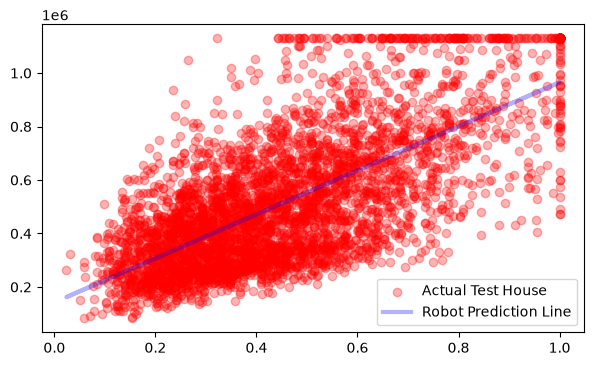

In [34]:
y_predict_simple=model.predict(x_test_simple)
plt.figure(figsize=(7,4))
plt.scatter(x_test_simple['scaled_size'],y_test,
            color='red',alpha=0.3,label='Actual Test House')
plt.plot(x_test_simple['scaled_size'],y_predict_simple,
         color='blue',alpha=0.3,linewidth=3,label='Robot Prediction Line')
plt.legend()

In [38]:
multiple_model=LinearRegression()
multiple_model.fit(x_train,y_train)
y_predict_multiple=multiple_model.predict(x_test)
print(y_predict_simple)
print(y_predict_multiple)

[513754.06569843 686863.30569022 868315.15965752 ... 589671.85287555
 551295.82858822 618036.74039228]
[524128.18921278 691477.18843096 864395.59042167 ... 571036.9181263
 534453.70576409 600718.9874884 ]


In [46]:
custom_house=pd.DataFrame([{
    'bedrooms':3.0,
    'bathrooms':2.0,
    'scaled_size':0.35,
    'floors':2.0,
    'waterfront':0,
    'sqft_living':1800.0,
    'condition':4,
    'loc_budget':0,
    'loc_mid-range':1,
    'loc_premium':0
}])
custom_house=custom_house[x_train.columns]
predicted_price=multiple_model.predict(custom_house)[0]
print(f"predicted price :${predicted_price:,.2f}")

predicted price :$506,195.81
